In [1]:
# Plotting time series of global mortality

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from utils.utils import land_filter
from utils.utils import autosize_figure

In [3]:
# === Path config ===
DIR = "/glade/work/awells/air_quality/CESM/mortality/"

ssp245 = xr.open_dataarray(f"{DIR}Mortality_global_sum_CESM2_SSP245_2020-2068.nc")
arise = xr.open_dataarray(f"{DIR}Mortality_global_sum_CESM2_ARISE_2035-2068.nc")

Text(0.5, 1.0, 'Difference in Global Mortality')

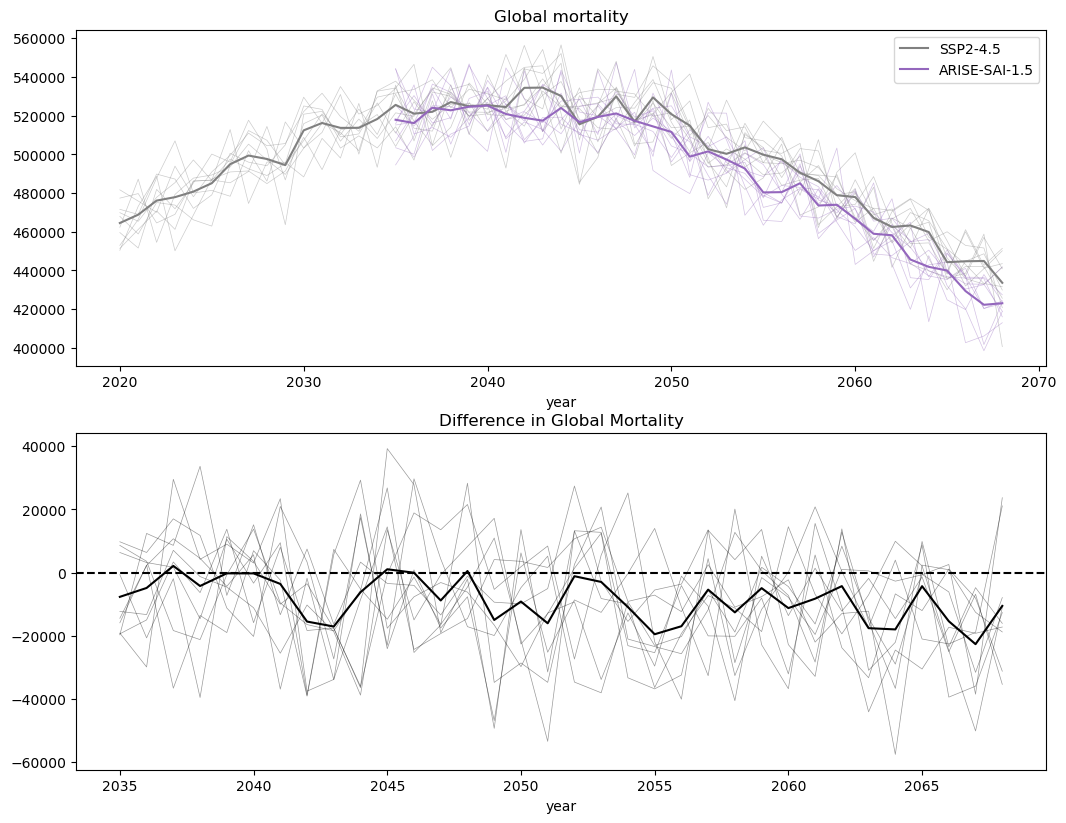

In [4]:
fig = plt.figure(figsize=autosize_figure(2, 1, xscale_factor=1.5))
gs = GridSpec(2, 1) # rows, columns

ax1 = fig.add_subplot(gs[0, 0])
for ens_num in range(1, 11):
    ssp245.sel(ensemble=ens_num, quantile="mean").plot(color='grey', alpha=0.4, linewidth=0.5)
    arise.sel(ensemble=ens_num, quantile="mean").plot(color='tab:purple', alpha=0.4, linewidth=0.5)
ssp245.mean("ensemble").sel(quantile="mean").plot(color='grey', label="SSP2-4.5")
arise.mean("ensemble").sel(quantile="mean").plot(color='tab:purple', label="ARISE-SAI-1.5")
plt.title("Global mortality")
plt.legend()

ax2 = fig.add_subplot(gs[1, 0])
ssp245_time = ssp245.sel(year=slice(2035, 2068))
for ens_num in range(1, 11):
    (arise - ssp245_time).sel(ensemble=ens_num, quantile="mean").plot(color='k', alpha=0.4, linewidth=0.5)
(arise - ssp245_time).mean("ensemble").sel(quantile="mean").plot(color='k')
plt.axhline(0, color='k', linestyle='--')
plt.title("Difference in Global Mortality")